In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# ============================================================
# 데이터 소개
# ============================================================

# - 공정(Process) 데이터
#     - Shot ID: 주조 샷 고유 식별자
#     - Injection Speed: 용탕 주입 속도 (m/s)
#     - Die Temperature: 금형 온도 (°C)
#     - Casting Pressure: 주조 압력 (bar)
#     - Cooling Time: 냉각 시간 (s)

# - 센서(Sensor) 데이터
#     - Mold Temp Sensor: 금형 내 센서 온도 (°C)
#     - Hydraulic Pressure: 유압 압력 (bar)
#     - Vibration Sensor: 진동값 (Hz)
#     - Flow Rate Sensor: 유량 (L/min)

# - 불량(Defects) 데이터
#     - Defect Type: 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
#     - Defect Status: 양품(0) / 불량(1) 여부

In [3]:
df = pd.read_csv("../../data/DieCasting_Quality_Preprocessed.csv", header=[0, 1])
df_origin = df.copy()
print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nArticles: {df.shape}")

print("\n[Data Info]")
df.info()

데이터 로드 완료!

Articles: (7535, 58)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness)    7535 non-null   int64  
 10  (Process, Clamping_Force)       7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12 

In [4]:
display(df.head())

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                      \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness Clamping_Force   
0               214           0.008                10            258   
1               217           0.008                11            257   
2               214           0.008                11            257   
3               217           0.008                11            257   
4               217           0.008                12            257   

                                                                          \
  Cycle_Time Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7              0.044             1037        7.8          0.7   
1       20.7              0.044             1052        7.8          0.7   
2       20.8              0.041             1037        7.8          0.7   
3       20.7              0.043             1051        7.8          0.7   
4       20.7              0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0             0   
4        0 

In [5]:
display(df.describe())

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                                                                        \
      Biscuit_Thickness Clamping_Force   Cycle_Time Pressure_Rise_Time   
count       7535.000000    7535.000000  7535.000000        7535.000000   
mean          14.309622     306.433311    27.735979           0.039348   
std            3.286284      57.274965     8.716156           0.003945   
min            0.000000     238.000000    20.200000           0.000000   
25%           11.000000     255.000000    20.900000           0.036000   
50%           13.000000     258.000000    22.600000           0.041000   
75%           17.000000     372.000000    35.900000           0.043000   
max           24.000000     388.000000   218.600000           0.046000   

                                                               \
      Casting_Pressure   Spray_Time Spray_1_Time Spray_2_Time   
count      7535.000000  7535.000000  7535.000000  7535.000000   
mean        856.944127     9.815979     1.409104     1.396045   
std         234.815490     1.842438     0.557060     0.716170   
min         516.000000     7.000000     0.700000     0.700000   
25%         596.000000     8.000000     0.800000     0.800000   
50%        1037.000000     9.700000     1.200000     0.800000   
75%        1053.000000    12.100000     2.000000     2.000000   
max        1164.000000    13.100000     2.500000     3.000000   

                    Sensor                                                 \
      Melting_Furnace_Temp Air_Pressure Air_Pressure_Min Air_Pressure_Max   
count          7535.000000  7535.000000           7535.0           7535.0   
mean            680.652661     6.109595              3.0              9.0   
std              25.288666     0.647906              0.0              0.0   
min             635.300000     4.600000              3.0              9.0   
25%             656.700000     5.700000              3.0              9.0   
50%             680.300000     6.200000              3.0              9.0   
75%             703.100000     6.600000              3.0              9.0   
max             730.000000     7.100000              3.0              9.0   

                                                                       \
      Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max Coolant_Pressure   
count  7535.000000           7535.0           7535.0      7535.000000   
mean     26.830126             10.0             50.0         2.701155   
std       0.525149              0.0              0.0         0.052408   
min      25.900000             1

In [9]:
df["Defects", "Defect_Flag"]

0       0
1       0
2       0
3       1
4       0
       ..
7530    0
7531    1
7532    1
7533    1
7534    1
Name: (Defects, Defect_Flag), Length: 7535, dtype: int64

In [10]:
process_cols = df["Process"].columns
sensor_cols = df["Sensor"].columns

features = list(process_cols) + list(sensor_cols)

X = pd.concat([df["Process"], df["Sensor"]], axis=1)
y = df[("Defects","Defect_Flag")]

corr = X.corrwith(y)
corr = corr.sort_values(ascending=False)

print(corr)

Clamping_Force          0.142831
Rapid_Rise_Time         0.132745
Product_Type            0.130745
Spray_1_Time            0.124848
Spray_Time              0.110987
Spray_2_Time            0.106157
Cycle_Time              0.104223
Biscuit_Thickness       0.095882
Cylinder_Pressure       0.093212
High_Velocity           0.093074
Coolant_Pressure        0.085504
Velocity_1              0.076692
Velocity_3              0.072150
Air_Pressure            0.067146
id                      0.018860
Factory_Temp            0.013096
Velocity_2             -0.024751
Pressure_Rise_Time     -0.054369
Shot                   -0.068725
Factory_Humidity       -0.072032
Coolant_Temp           -0.085563
Casting_Pressure       -0.145151
Melting_Furnace_Temp   -0.145568
Air_Pressure_Min             NaN
Air_Pressure_Max             NaN
Coolant_Temp_Min             NaN
Coolant_Temp_Max             NaN
Factory_Temp_Min             NaN
Factory_Temp_Max             NaN
Factory_Humidity_Min         NaN
Factory_Hu

<Axes: xlabel="('Defects', 'Defect_Flag')", ylabel='count'>

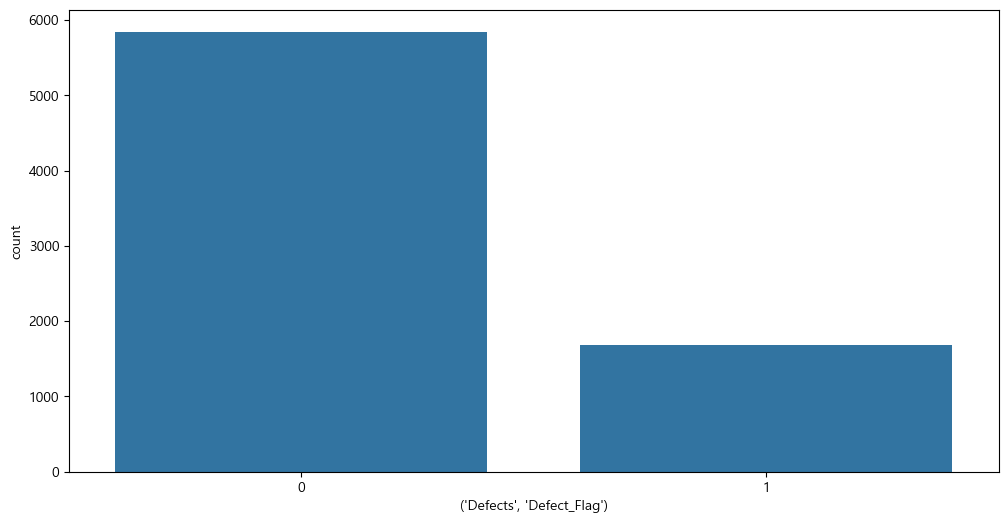

In [11]:
sns.countplot(x=df[("Defects","Defect_Flag")])